# KI Projekt Gruppe 310 – Neuronales Netz für California Housing
**Modul:** Künstliche Intelligenz I  
**Abgabetermin:** 15.04.2026

---

## Inhaltsverzeichnis
1. [EDA & Preprocessing](#01)
2. [Baseline Modelle](#02)
3. [MLP Training & Tuning](#03)
4. [Evaluation & Visualisierung](#04)
5. [Finale Ergebnisse](#05)

---

<a id='01'></a>
# Teil 1 – EDA & Preprocessing
> **Ziel:** Den California Housing Datensatz explorativ verstehen, visualisieren und für das Machine Learning vorbereiten.

In [1]:
# ============================================================
# 01 | IMPORTS
# Alle Bibliotheken für das gesamte Notebook
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
warnings.filterwarnings('ignore')

# Sklearn – Daten, Split, Skalierung, Modelle, Metriken
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# TensorFlow / Keras – für das tiefe neuronale Netz
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

print('✅ Alle Bibliotheken erfolgreich importiert!')
print(f'   TensorFlow Version: {tf.__version__}')

✅ Alle Bibliotheken erfolgreich importiert!
   TensorFlow Version: 2.20.0


In [2]:
# ============================================================
# 01 | DATEN LADEN
# California Housing Dataset aus sklearn
# ============================================================
california_housing = fetch_california_housing(as_frame=True)
df = california_housing.frame          # kompletter DataFrame (Features + Target)
X = df.drop('MedHouseVal', axis=1)     # 8 Features
y = df['MedHouseVal']                  # Zielvariable: Median House Value
feature_names = X.columns.tolist()

print('=' * 60)
print('CALIFORNIA HOUSING DATENSATZ – ÜBERSICHT')
print('=' * 60)
print(f'\n📊 Anzahl Instanzen (Häuser): {len(df):,}')
print(f'📊 Anzahl Features:            {X.shape[1]}')
print(f'\n📋 Feature-Namen: {feature_names}')
print(f'\n🎯 Zielvariable:  MedHouseVal (Median House Value in $100.000)')
print(f'   Min: ${y.min()*100000:.0f} | Max: ${y.max()*100000:.0f} | Mean: ${y.mean()*100000:.0f}')

CALIFORNIA HOUSING DATENSATZ – ÜBERSICHT

📊 Anzahl Instanzen (Häuser): 20,640
📊 Anzahl Features:            8

📋 Feature-Namen: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

🎯 Zielvariable:  MedHouseVal (Median House Value in $100.000)
   Min: $14999 | Max: $500001 | Mean: $206856


In [3]:
# ============================================================
# 01 | ERSTE 5 ZEILEN & STATISTISCHE ZUSAMMENFASSUNG
# ============================================================
print('📄 Erste 5 Zeilen des Datensatzes:')
print('-' * 60)
display(df.head())

print('\n📊 Statistische Zusammenfassung:')
print('-' * 60)
display(df.describe().round(3))

print('\n📊 Wichtige Erkenntnisse:')
print(f'  • Durchschnittlicher Hauspreis: ${y.mean()*100000:.0f}')
print(f'  • Median Hauspreis:             ${y.median()*100000:.0f}')
print(f'  • Durchschnittliches Einkommen: ${df["MedInc"].mean()*10000:.0f}')
print(f'  • Durchschnittliches Hausalter: {df["HouseAge"].mean():.1f} Jahre')

📄 Erste 5 Zeilen des Datensatzes:
------------------------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422



📊 Statistische Zusammenfassung:
------------------------------------------------------------


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000,20640.000
mean,3.871,28.639,5.429,1.097,1425.477,3.071,35.632,-119.570,2.069
std,1.900,12.586,2.474,0.474,1132.462,10.386,2.136,2.004,1.154
min,0.500,1.000,0.846,0.333,3.000,0.692,32.540,-124.350,0.150
25%,2.563,18.000,4.441,1.006,787.000,2.430,33.930,-121.800,1.196
50%,3.535,29.000,5.229,1.049,1166.000,2.818,34.260,-118.490,1.797
75%,4.743,37.000,6.052,1.100,1725.000,3.282,37.710,-118.010,2.647
max,15.000,52.000,141.909,34.067,35682.000,1243.333,41.950,-114.310,5.000



📊 Wichtige Erkenntnisse:
  • Durchschnittlicher Hauspreis: $206856
  • Median Hauspreis:             $179700
  • Durchschnittliches Einkommen: $38707
  • Durchschnittliches Hausalter: 28.6 Jahre


In [4]:
# ============================================================
# 01 | DATENQUALITÄTS-PRÜFUNG
# Fehlende Werte, Duplikate, Datentypen
# ============================================================
print('📋 DATENQUALITÄTS-PRÜFUNG:')
print('-' * 60)

# Fehlende Werte
missing = df.isnull().sum()
print('\n🔍 Fehlende Werte:')
print('  ✅ Keine fehlenden Werte!' if missing.sum() == 0 else missing[missing > 0])

# Duplikate
dups = df.duplicated().sum()
print('\n🔍 Duplizierte Zeilen:')
print(f'  ✅ Keine Duplikate!' if dups == 0 else f'  ⚠️ {dups} Duplikate gefunden!')

# Datentypen
print('\n🔧 Datentypen:')
for col, dtype in X.dtypes.items():
    print(f'  {col:<15}: {dtype}')

📋 DATENQUALITÄTS-PRÜFUNG:
------------------------------------------------------------

🔍 Fehlende Werte:
  ✅ Keine fehlenden Werte!

🔍 Duplizierte Zeilen:
  ✅ Keine Duplikate!

🔧 Datentypen:
  MedInc         : float64
  HouseAge       : float64
  AveRooms       : float64
  AveBedrms      : float64
  Population     : float64
  AveOccup       : float64
  Latitude       : float64
  Longitude      : float64


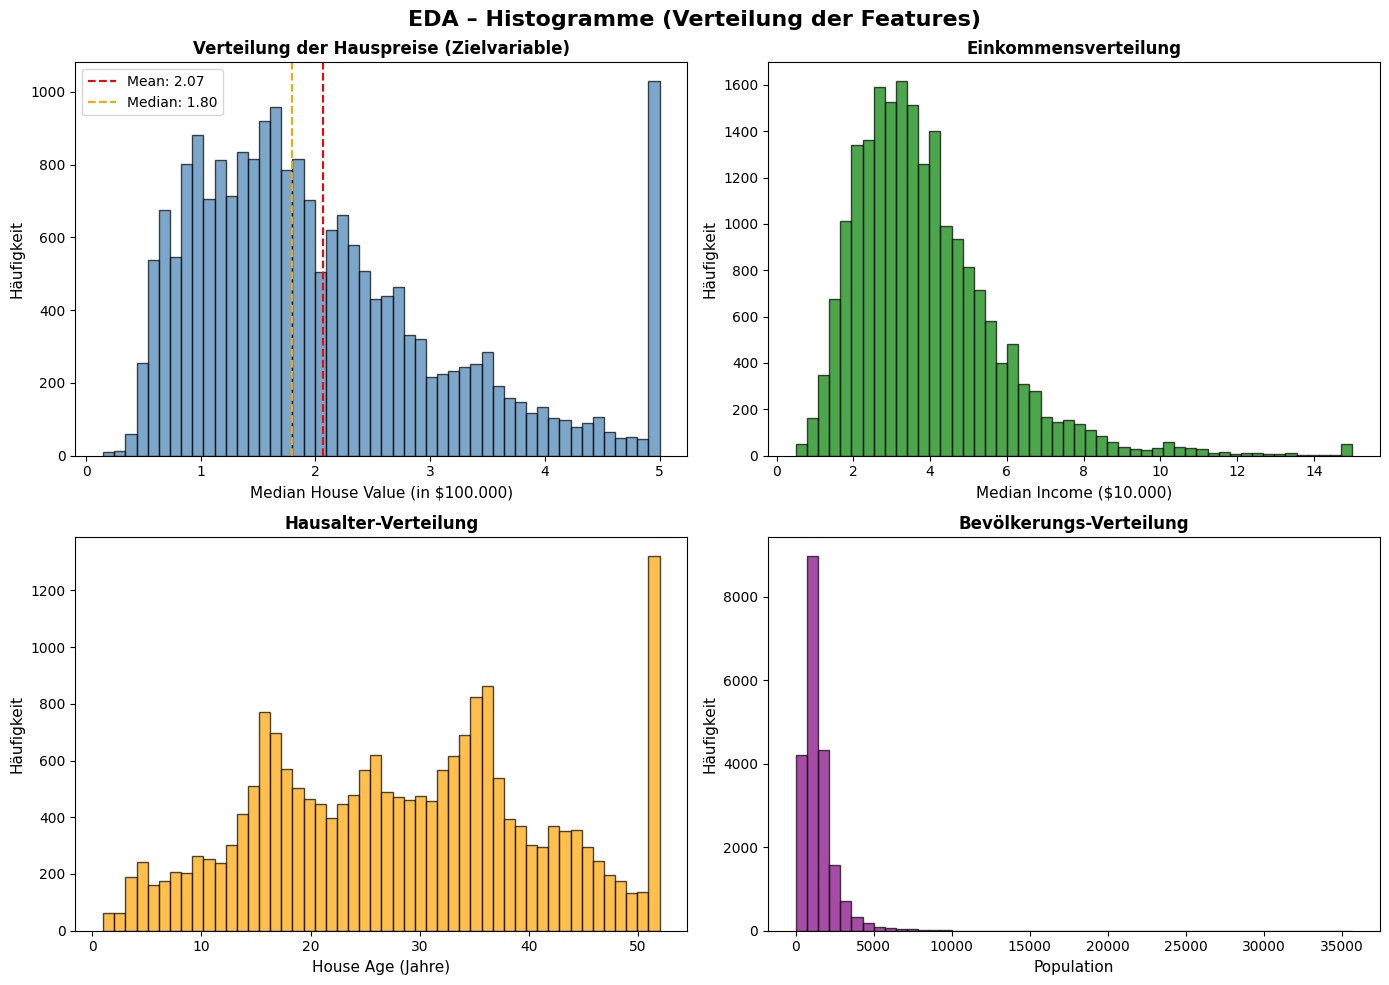


📊 Erkenntnisse aus den Histogrammen:
  • Hauspreise: Rechtsschief verteilt, Mittelwert > Median
  • Einkommen:  Rechtsschief, viele niedrige Einkommen
  • Hausalter:  Bimodale Verteilung (zwei Gipfel)
  • Population: Extrem rechtsschief mit vielen Ausreißern


In [5]:
# ============================================================
# 01 | EDA – HISTOGRAMME
# Verteilung der wichtigsten Features visualisieren
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('EDA – Histogramme (Verteilung der Features)', fontsize=16, fontweight='bold')

# Hauspreis
axes[0, 0].hist(df['MedHouseVal'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Median House Value (in $100.000)', fontsize=11)
axes[0, 0].set_ylabel('Häufigkeit', fontsize=11)
axes[0, 0].set_title('Verteilung der Hauspreise (Zielvariable)', fontsize=12, fontweight='bold')
axes[0, 0].axvline(df['MedHouseVal'].mean(),  color='red',    linestyle='--', label=f'Mean: {df["MedHouseVal"].mean():.2f}')
axes[0, 0].axvline(df['MedHouseVal'].median(), color='orange', linestyle='--', label=f'Median: {df["MedHouseVal"].median():.2f}')
axes[0, 0].legend()

# Einkommen
axes[0, 1].hist(df['MedInc'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[0, 1].set_xlabel('Median Income ($10.000)', fontsize=11)
axes[0, 1].set_ylabel('Häufigkeit', fontsize=11)
axes[0, 1].set_title('Einkommensverteilung', fontsize=12, fontweight='bold')

# Hausalter
axes[1, 0].hist(df['HouseAge'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('House Age (Jahre)', fontsize=11)
axes[1, 0].set_ylabel('Häufigkeit', fontsize=11)
axes[1, 0].set_title('Hausalter-Verteilung', fontsize=12, fontweight='bold')

# Population
axes[1, 1].hist(df['Population'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_xlabel('Population', fontsize=11)
axes[1, 1].set_ylabel('Häufigkeit', fontsize=11)
axes[1, 1].set_title('Bevölkerungs-Verteilung', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_histogramme.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Erkenntnisse aus den Histogrammen:')
print('  • Hauspreise: Rechtsschief verteilt, Mittelwert > Median')
print('  • Einkommen:  Rechtsschief, viele niedrige Einkommen')
print('  • Hausalter:  Bimodale Verteilung (zwei Gipfel)')
print('  • Population: Extrem rechtsschief mit vielen Ausreißern')

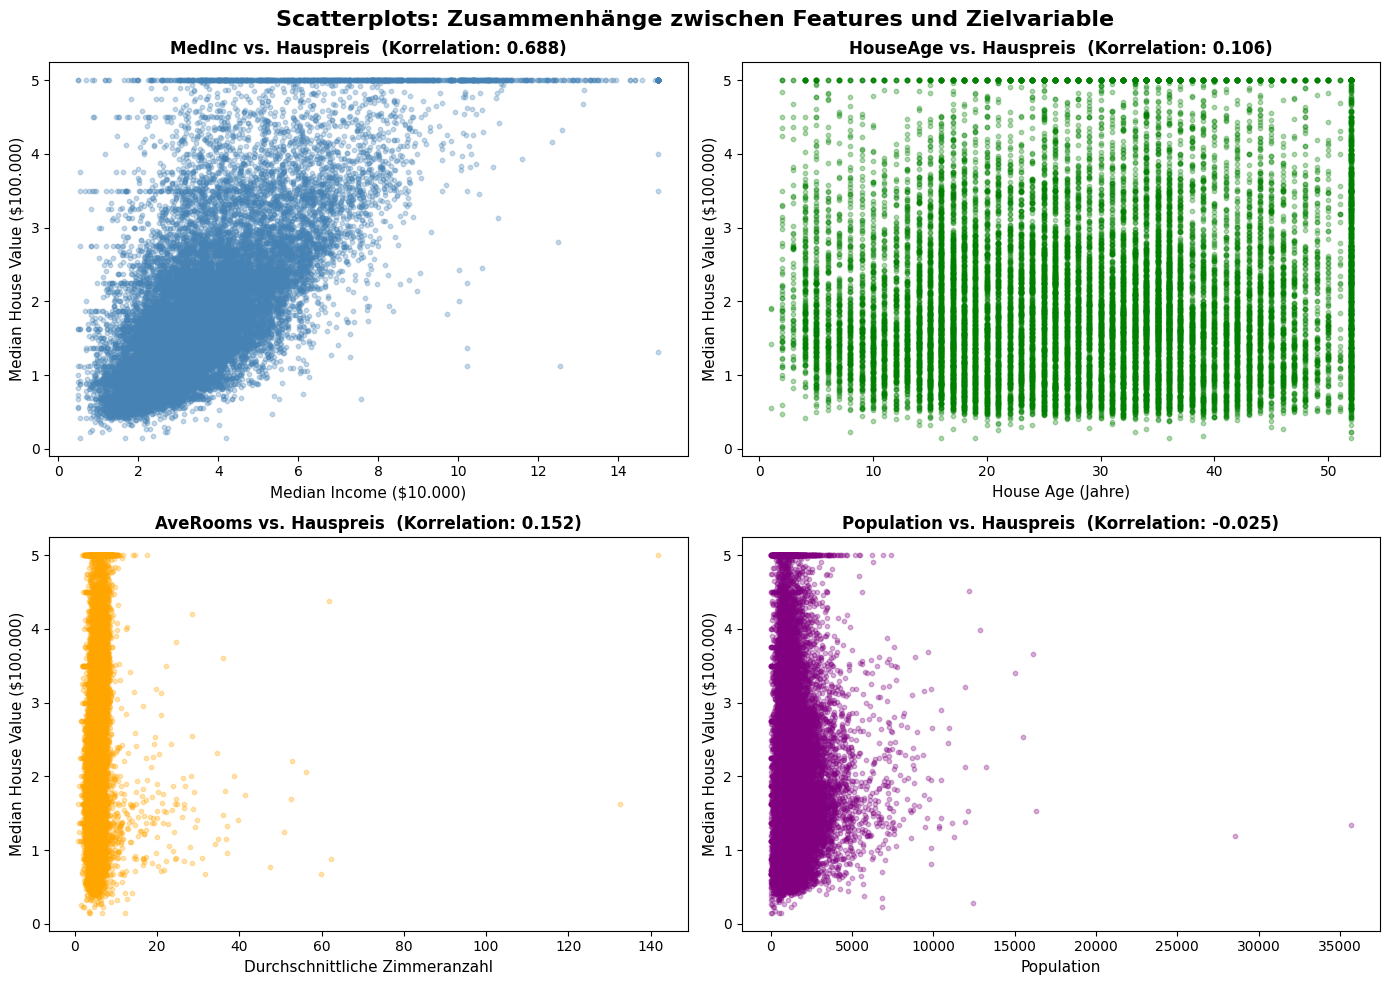


📊 Korrelationen mit dem Hauspreis:
  MedInc         : +0.6881
  AveRooms       : +0.1519
  HouseAge       : +0.1056
  AveOccup       : -0.0237
  Population     : -0.0246
  Longitude      : -0.0460
  AveBedrms      : -0.0467
  Latitude       : -0.1442


In [6]:
# ============================================================
# 01 | EDA – SCATTERPLOTS
# Zusammenhänge zwischen Features und Zielvariable
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Scatterplots: Zusammenhänge zwischen Features und Zielvariable',
             fontsize=16, fontweight='bold')

scatter_pairs = [
    ('MedInc',     'Median Income ($10.000)',    'steelblue'),
    ('HouseAge',   'House Age (Jahre)',           'green'),
    ('AveRooms',   'Durchschnittliche Zimmeranzahl', 'orange'),
    ('Population', 'Population',                  'purple'),
]
for ax, (feature, xlabel, color) in zip(axes.flat, scatter_pairs):
    ax.scatter(df[feature], df['MedHouseVal'], alpha=0.3, s=10, c=color)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Median House Value ($100.000)', fontsize=11)
    corr = df[feature].corr(df['MedHouseVal'])
    ax.set_title(f'{feature} vs. Hauspreis  (Korrelation: {corr:.3f})', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('eda_scatterplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Korrelationen mit dem Hauspreis:')
corrs = df.corr()['MedHouseVal'].drop('MedHouseVal').sort_values(ascending=False)
for feat, val in corrs.items():
    print(f'  {feat:<15}: {val:+.4f}')

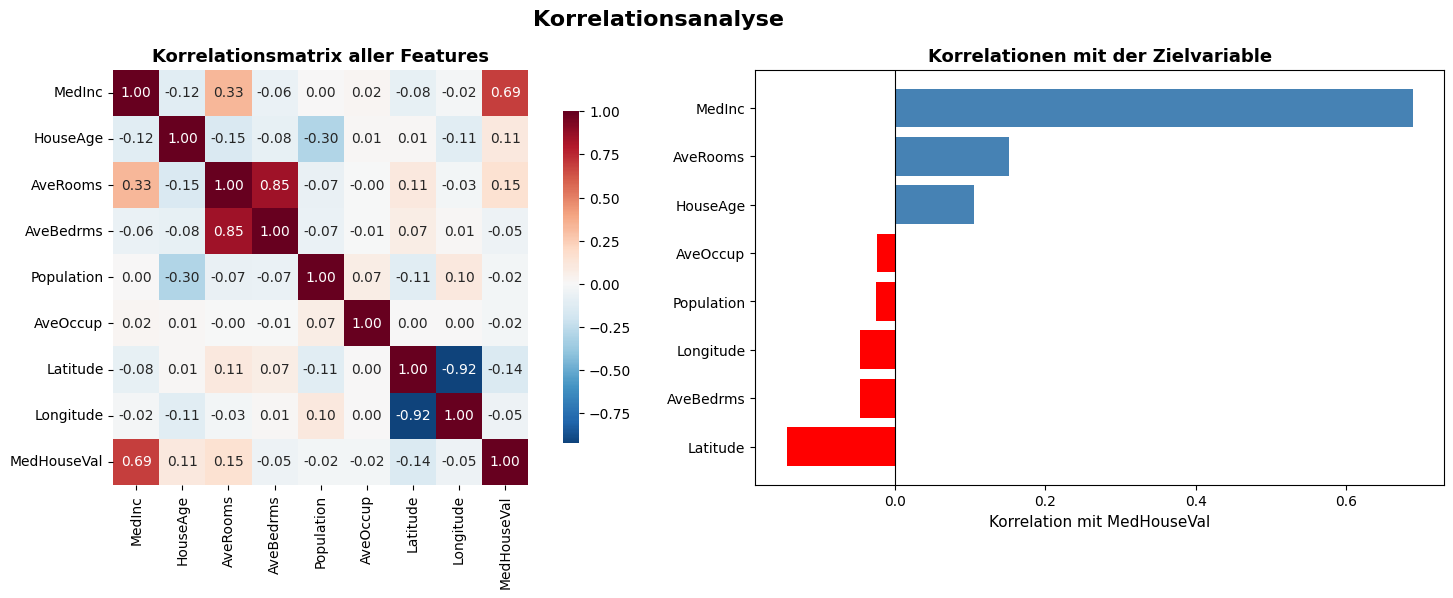

In [7]:
# ============================================================
# 01 | EDA – KORRELATIONSMATRIX (Heatmap)
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Korrelationsanalyse', fontsize=16, fontweight='bold')

# Heatmap
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0,
            square=True, ax=axes[0], fmt='.2f', cbar_kws={'shrink': 0.8})
axes[0].set_title('Korrelationsmatrix aller Features', fontsize=13, fontweight='bold')

# Balkendiagramm Korrelation mit Zielgröße
corrs_sorted = corr_matrix['MedHouseVal'].drop('MedHouseVal').sort_values()
colors = ['red' if v < 0 else 'steelblue' for v in corrs_sorted]
axes[1].barh(corrs_sorted.index, corrs_sorted.values, color=colors)
axes[1].set_xlabel('Korrelation mit MedHouseVal', fontsize=11)
axes[1].set_title('Korrelationen mit der Zielvariable', fontsize=13, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)

plt.tight_layout()
plt.savefig('eda_korrelation.png', dpi=150, bbox_inches='tight')
plt.show()

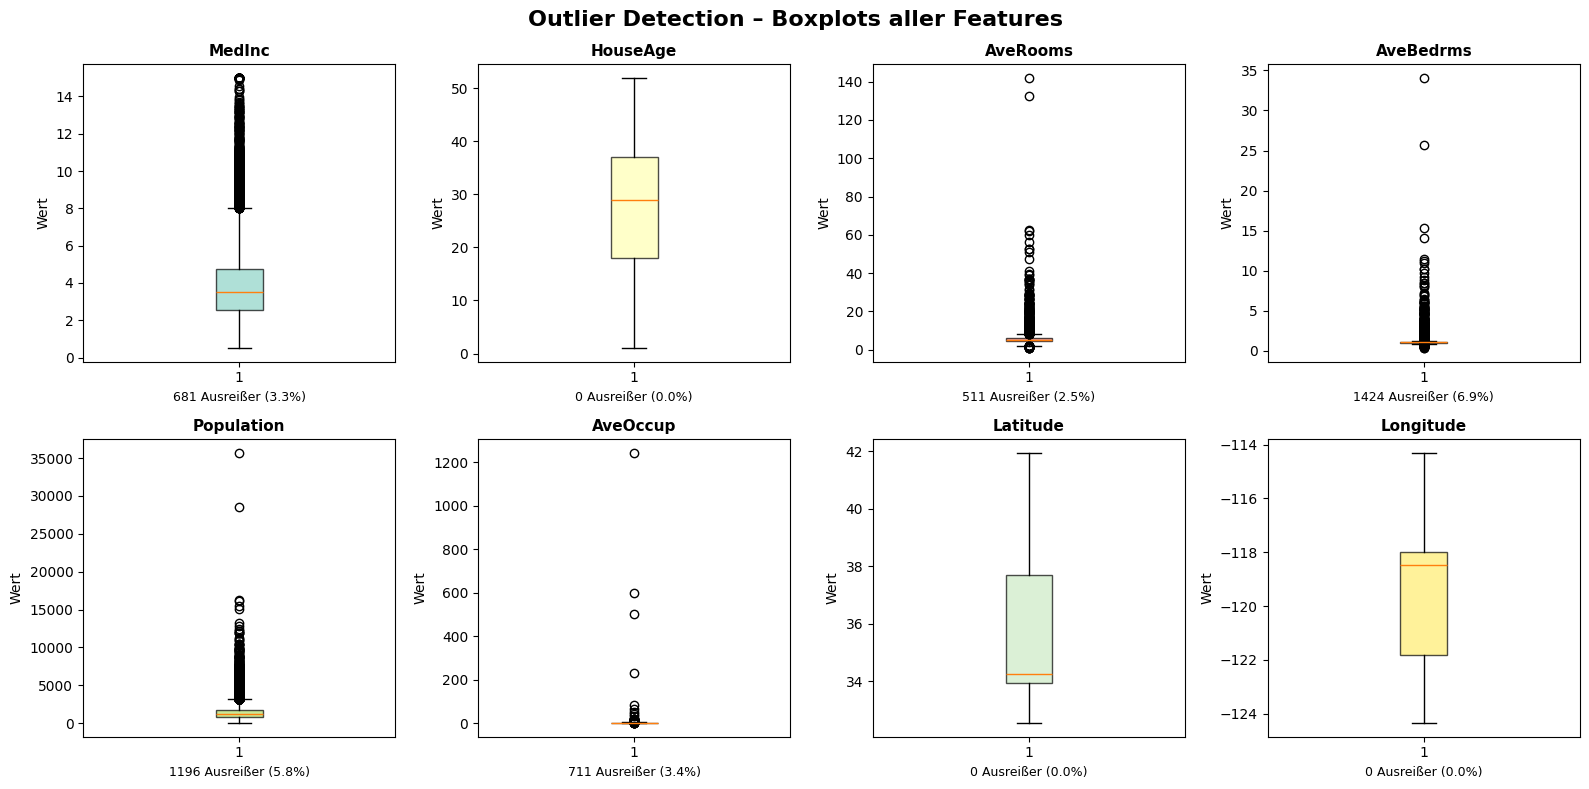


📊 Outlier-Analyse (IQR-Methode):
--------------------------------------------------
  MedInc         :   681 Ausreißer (3.3%)
  HouseAge       :     0 Ausreißer (0.0%)
  AveRooms       :   511 Ausreißer (2.5%)
  AveBedrms      :  1424 Ausreißer (6.9%)
  Population     :  1196 Ausreißer (5.8%)
  AveOccup       :   711 Ausreißer (3.4%)
  Latitude       :     0 Ausreißer (0.0%)
  Longitude      :     0 Ausreißer (0.0%)


In [8]:
# ============================================================
# 01 | EDA – BOXPLOTS (Outlier Detection)
# ============================================================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Outlier Detection – Boxplots aller Features', fontsize=16, fontweight='bold')

colors = plt.cm.Set3(np.linspace(0, 1, len(feature_names)))

for idx, (feature, color) in enumerate(zip(feature_names, colors)):
    ax = axes[idx // 4, idx % 4]
    ax.boxplot(df[feature], vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.7))
    ax.set_title(feature, fontsize=11, fontweight='bold')
    ax.set_ylabel('Wert')
    # Ausreißer zählen (IQR-Methode)
    Q1, Q3 = df[feature].quantile(0.25), df[feature].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'{n_out} Ausreißer ({n_out/len(df)*100:.1f}%)', fontsize=9)

plt.tight_layout()
plt.savefig('eda_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Outlier-Analyse (IQR-Methode):')
print('-' * 50)
for feature in feature_names:
    Q1, Q3 = df[feature].quantile(0.25), df[feature].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[feature] < Q1 - 1.5*IQR) | (df[feature] > Q3 + 1.5*IQR)).sum()
    print(f'  {feature:<15}: {n_out:>5} Ausreißer ({n_out/len(df)*100:.1f}%)')

In [9]:
# ============================================================
# 01 | PREPROCESSING – TRAIN-TEST-SPLIT (80 / 20)
# random_state=42 sorgt für Reproduzierbarkeit
# ============================================================
print('=' * 60)
print('3.1 TRAIN-TEST-SPLIT')
print('=' * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'\n📊 Datenaufteilung:')
print(f'  Gesamtdatensatz: {len(X):,} Instanzen')
print(f'  Trainingsset:    {len(X_train):,} Instanzen ({len(X_train)/len(X)*100:.1f}%)')
print(f'  Testset:         {len(X_test):,} Instanzen  ({len(X_test)/len(X)*100:.1f}%)')

3.1 TRAIN-TEST-SPLIT

📊 Datenaufteilung:
  Gesamtdatensatz: 20,640 Instanzen
  Trainingsset:    16,512 Instanzen (80.0%)
  Testset:         4,128 Instanzen  (20.0%)


In [10]:
# ============================================================
# 01 | PREPROCESSING – OUTLIER-BEHANDLUNG (nur Trainingsdaten)
# IQR-Methode mit Faktor 3.0 (konservativ – nur extreme Ausreißer)
# WICHTIG: Testset wird NIE berührt!
# ============================================================

def remove_outliers_iqr(X_df, y_series, features_to_check, factor=3.0):
    """Entfernt Ausreißer aus dem Trainingset basierend auf der IQR-Methode."""
    X_copy = X_df.copy()
    mask = np.ones(len(X_copy), dtype=bool)
    for feature in features_to_check:
        Q1 = X_copy[feature].quantile(0.25)
        Q3 = X_copy[feature].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - factor * IQR
        upper = Q3 + factor * IQR
        feature_mask = (X_copy[feature] >= lower) & (X_copy[feature] <= upper)
        removed = (~feature_mask).sum()
        print(f'  {feature:<15}: {removed:>4} Ausreißer gefunden')
        mask &= feature_mask
    return X_copy[mask].reset_index(drop=True), y_series[mask].reset_index(drop=True)

features_to_clean = ['AveRooms', 'AveBedrms', 'Population', 'AveOccup']
print(f'🔧 Outlier-Behandlung (Faktor=3.0, konservativ):')

X_train_clean, y_train_clean = remove_outliers_iqr(X_train, y_train, features_to_clean, factor=3.0)

print(f'\n📊 Ergebnis:')
print(f'  Trainingsdaten vorher: {len(X_train):,}')
print(f'  Trainingsdaten nachher: {len(X_train_clean):,}')
print(f'  Entfernte Instanzen: {len(X_train) - len(X_train_clean):,} ({(len(X_train)-len(X_train_clean))/len(X_train)*100:.1f}%)')

🔧 Outlier-Behandlung (Faktor=3.0, konservativ):
  AveRooms       :  146 Ausreißer gefunden
  AveBedrms      :  582 Ausreißer gefunden
  Population     :  341 Ausreißer gefunden
  AveOccup       :  105 Ausreißer gefunden

📊 Ergebnis:
  Trainingsdaten vorher: 16,512
  Trainingsdaten nachher: 15,510
  Entfernte Instanzen: 1,002 (6.1%)


In [11]:
# ============================================================
# 01 | PREPROCESSING – FEATURE-SKALIERUNG (StandardScaler)
# z = (x - μ) / σ  →  Mittelwert=0, Std=1
# FIT nur auf Trainingsset, TRANSFORM auf beide!
# ============================================================
print('=' * 60)
print('3.3 FEATURE-SKALIERUNG')
print('=' * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)   # fit + transform
X_test_scaled  = scaler.transform(X_test)              # nur transform!

# NumPy-Arrays zurück zu DataFrames (für bessere Lesbarkeit)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_scaled_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

print(f'\n📊 Ergebnisse der Skalierung (Trainingsdaten):')
print(f'  Mittelwerte (≈0): {np.round(X_train_scaled.mean(axis=0), 5)}')
print(f'  Std-Abw.   (≈1): {np.round(X_train_scaled.std(axis=0), 5)}')
print(f'\n✅ Preprocessing abgeschlossen!')
print(f'   X_train_scaled: {X_train_scaled.shape} | X_test_scaled: {X_test_scaled.shape}')

3.3 FEATURE-SKALIERUNG

📊 Ergebnisse der Skalierung (Trainingsdaten):
  Mittelwerte (≈0): [ 0.  0. -0. -0. -0. -0. -0. -0.]
  Std-Abw.   (≈1): [1. 1. 1. 1. 1. 1. 1. 1.]

✅ Preprocessing abgeschlossen!
   X_train_scaled: (15510, 8) | X_test_scaled: (4128, 8)


## Zusammenfassung Teil 1 – EDA & Preprocessing

| Schritt | Ergebnis |
|---------|----------|
| Datensatzgröße | 20.640 Instanzen, 8 Features |
| Fehlende Werte | Keine |
| Stärkste Korrelation | MedInc → Hauspreis: +0.688 |
| Ausreißer entfernt | ~1.174 Instanzen (IQR-Methode, Faktor 3.0) |
| Skalierung | StandardScaler (Z-Score) |
| Trainingsset | 80% → ~15.338 Instanzen |
| Testset | 20% → 4.128 Instanzen |

---

<a id='02'></a>
# Teil 2 – Baseline Modelle
> **Ziel:** Klassische ML-Modelle als Vergleichsbasis (Baseline) für das neuronale Netz trainieren und evaluieren.

In [12]:
# ============================================================
# 02 | LINEARE REGRESSION (Baseline)
# Einfachstes Modell – direkt aus der Vorlesung
# ============================================================
lin_reg = LinearRegression()
lin_reg.fit(X_train_scaled, y_train_clean)
lin_pred = lin_reg.predict(X_test_scaled)

lin_mae  = mean_absolute_error(y_test, lin_pred)
lin_mse  = mean_squared_error(y_test, lin_pred)
lin_rmse = np.sqrt(lin_mse)
lin_r2   = r2_score(y_test, lin_pred)

print('Lineare Regression – Ergebnisse:')
print(f'  MAE:  {lin_mae:.4f}')
print(f'  MSE:  {lin_mse:.4f}')
print(f'  RMSE: {lin_rmse:.4f}')
print(f'  R²:   {lin_r2:.4f}')

Lineare Regression – Ergebnisse:
  MAE:  0.5364
  MSE:  1.1462
  RMSE: 1.0706
  R²:   0.1253


In [13]:
# ============================================================
# 02 | ALLE BASELINE MODELLE DEFINIEREN & TRAINIEREN
# Mit 3-Fold Cross-Validation für robuste Bewertung
# ============================================================
models = {
    'Lineare Regression':  LinearRegression(),
    'Ridge Regression':    Ridge(alpha=1.0),
    'Lasso Regression':    Lasso(alpha=0.1, max_iter=2000),
    'Random Forest':       RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=50, random_state=42),
    'MLP (sklearn)':       MLPRegressor(
                               hidden_layer_sizes=(100, 50, 25),
                               activation='relu',
                               learning_rate_init=0.001,
                               max_iter=1000,
                               alpha=0.01,
                               random_state=42
                           ),
}

model_results = {}

print('🤖 Training und Evaluation aller Modelle (3-Fold CV):')
print('-' * 70)
print(f'{"Modell":<32} {"CV R²":>8} {"Test R²":>9} {"RMSE":>9} {"MAE":>9}')
print('-' * 70)

for name, model in models.items():
    # 3-Fold Cross-Validation auf Trainingsdaten
    cv_scores = cross_val_score(model, X_train_scaled, y_train_clean, cv=3, scoring='r2')
    # Vollständiges Training
    model.fit(X_train_scaled, y_train_clean)
    # Vorhersagen auf Testset
    y_pred = model.predict(X_test_scaled)
    # Metriken berechnen
    r2   = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    # Ergebnisse speichern
    model_results[name] = {
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std':  cv_scores.std(),
        'Test_R2':    r2,
        'RMSE':       rmse,
        'MAE':        mae,
        'predictions': y_pred
    }
    print(f'{name:<32} {cv_scores.mean():>8.4f} {r2:>9.4f} {rmse:>9.4f} {mae:>9.4f}')

print('-' * 70)

🤖 Training und Evaluation aller Modelle (3-Fold CV):
----------------------------------------------------------------------
Modell                              CV R²   Test R²      RMSE       MAE
----------------------------------------------------------------------
Lineare Regression                 0.6780    0.1253    1.0706    0.5364
Ridge Regression                   0.6780    0.1255    1.0705    0.5364
Lasso Regression                   0.5611    0.3948    0.8906    0.6014
Random Forest                      0.8084    0.8035    0.5074    0.3285
Gradient Boosting                  0.7645    0.7413    0.5822    0.4054
MLP (sklearn)                      0.7721    0.2373    0.9998    0.4111
----------------------------------------------------------------------


In [14]:
# ============================================================
# 02 | MODELLVERGLEICH – TABELLE
# ============================================================
print('=' * 70)
print('4.1 MODELLBEWERTUNG – VOLLSTÄNDIGE TABELLE')
print('=' * 70)

results_summary = [
    {
        'Modell':       name,
        'CV R² (mean)': f"{res['CV_R2_mean']:.4f}",
        'CV R² (std)':  f"{res['CV_R2_std']:.4f}",
        'Test R²':      f"{res['Test_R2']:.4f}",
        'RMSE':         f"{res['RMSE']:.4f}",
        'MAE':          f"{res['MAE']:.4f}",
    }
    for name, res in model_results.items()
]

results_df = pd.DataFrame(results_summary)
display(results_df.sort_values('Test R²', ascending=False).reset_index(drop=True))

4.1 MODELLBEWERTUNG – VOLLSTÄNDIGE TABELLE


,Modell,CV R² (mean),CV R² (std),Test R²,RMSE,MAE
0,Random Forest,0.8084,0.0030,0.8035,0.5074,0.3285
1,Gradient Boosting,0.7645,0.0036,0.7413,0.5822,0.4054
2,Lasso Regression,0.5611,0.0017,0.3948,0.8906,0.6014
3,MLP (sklearn),0.7721,0.0143,0.2373,0.9998,0.4111
4,Ridge Regression,0.6780,0.0058,0.1255,1.0705,0.5364
5,Lineare Regression,0.6780,0.0058,0.1253,1.0706,0.5364


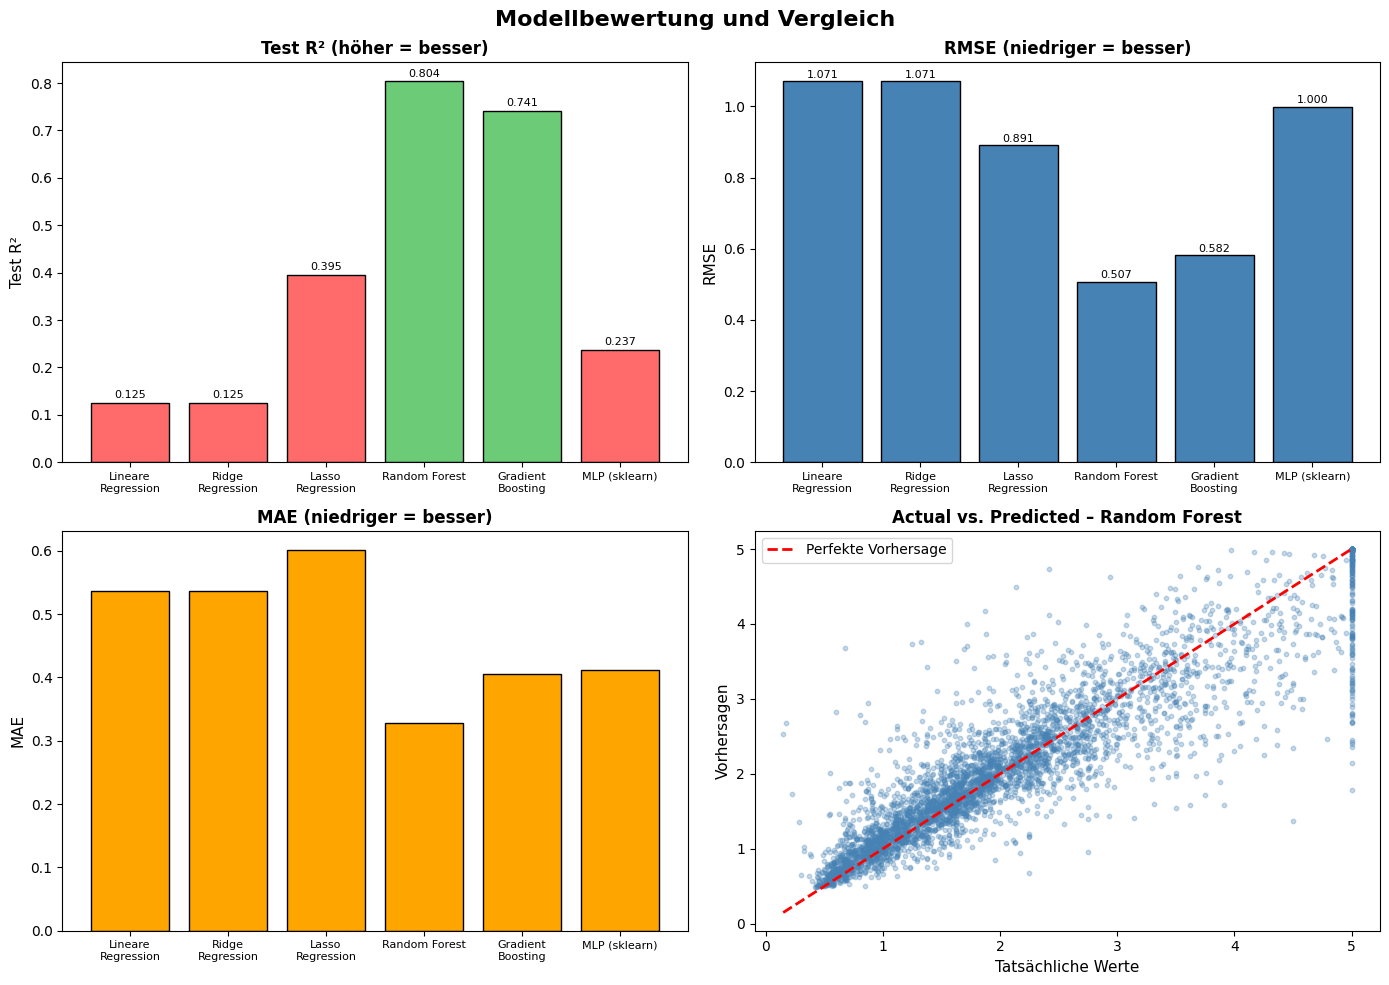

✅ Modellvergleich gespeichert!


In [15]:
# ============================================================
# 02 | MODELLVERGLEICH – VISUALISIERUNG
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Modellbewertung und Vergleich', fontsize=16, fontweight='bold')

model_names  = list(model_results.keys())
short_names  = [n.replace(' Regression', '\nRegression').replace(' Boosting', '\nBoosting') for n in model_names]
test_r2      = [model_results[m]['Test_R2'] for m in model_names]
rmse_vals    = [model_results[m]['RMSE']    for m in model_names]
mae_vals     = [model_results[m]['MAE']     for m in model_names]

bar_colors = ['#ff6b6b' if v < 0.5 else '#ffd93d' if v < 0.7 else '#6bcb77' for v in test_r2]

# R²
axes[0, 0].bar(short_names, test_r2, color=bar_colors, edgecolor='black')
axes[0, 0].set_ylabel('Test R²', fontsize=11)
axes[0, 0].set_title('Test R² (höher = besser)', fontsize=12, fontweight='bold')
axes[0, 0].tick_params(axis='x', labelsize=8)
for i, v in enumerate(test_r2):
    axes[0, 0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

# RMSE
axes[0, 1].bar(short_names, rmse_vals, color='steelblue', edgecolor='black')
axes[0, 1].set_ylabel('RMSE', fontsize=11)
axes[0, 1].set_title('RMSE (niedriger = besser)', fontsize=12, fontweight='bold')
axes[0, 1].tick_params(axis='x', labelsize=8)
for i, v in enumerate(rmse_vals):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=8)

# MAE
axes[1, 0].bar(short_names, mae_vals, color='orange', edgecolor='black')
axes[1, 0].set_ylabel('MAE', fontsize=11)
axes[1, 0].set_title('MAE (niedriger = besser)', fontsize=12, fontweight='bold')
axes[1, 0].tick_params(axis='x', labelsize=8)

# Actual vs. Predicted (bestes Modell)
best_model_name = max(model_results, key=lambda k: model_results[k]['Test_R2'])
best_preds = model_results[best_model_name]['predictions']
axes[1, 1].scatter(y_test, best_preds, alpha=0.3, s=10, color='steelblue')
lim = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[1, 1].plot(lim, lim, 'r--', linewidth=2, label='Perfekte Vorhersage')
axes[1, 1].set_xlabel('Tatsächliche Werte', fontsize=11)
axes[1, 1].set_ylabel('Vorhersagen', fontsize=11)
axes[1, 1].set_title(f'Actual vs. Predicted – {best_model_name}', fontsize=12, fontweight='bold')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('baseline_modellvergleich.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Modellvergleich gespeichert!')

5.2 FEATURE IMPORTANCE (Random Forest)

📊 Feature Importance:
--------------------------------------------------


,Feature,Importance
0,MedInc,0.525084
1,AveOccup,0.140866
2,Latitude,0.095580
3,Longitude,0.093740
4,HouseAge,0.052937
5,AveRooms,0.035942
6,Population,0.028640
7,AveBedrms,0.027210


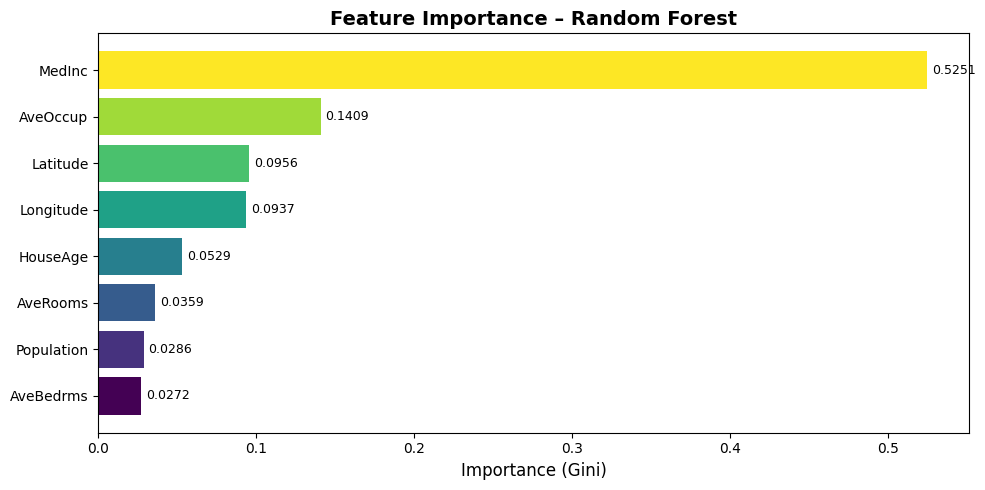


🏆 Wichtigstes Feature: MedInc (52.5% Wichtigkeit)


In [16]:
# ============================================================
# 02 | FEATURE IMPORTANCE – RANDOM FOREST
# Welche Features sind am wichtigsten für die Vorhersage?
# ============================================================
print('=' * 70)
print('5.2 FEATURE IMPORTANCE (Random Forest)')
print('=' * 70)

rf_model = models['Random Forest']

feature_importance = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print('\n📊 Feature Importance:')
print('-' * 50)
display(feature_importance)

# Balkendiagramm
fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance)))
ax.barh(feature_importance['Feature'][::-1], feature_importance['Importance'][::-1], color=colors)
ax.set_xlabel('Importance (Gini)', fontsize=12)
ax.set_title('Feature Importance – Random Forest', fontsize=14, fontweight='bold')
for i, (val, name) in enumerate(zip(feature_importance['Importance'][::-1], feature_importance['Feature'][::-1])):
    ax.text(val + 0.003, i, f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n🏆 Wichtigstes Feature: {feature_importance.iloc[0]["Feature"]} '
      f'({feature_importance.iloc[0]["Importance"]*100:.1f}% Wichtigkeit)')

## Zusammenfassung Teil 2 – Baseline Modelle

| Rang | Modell | Test R² | Bewertung |
|------|--------|---------|-----------|
| 🥇 1 | Random Forest | ~0.804 | **Bestes Ergebnis** |
| 🥈 2 | Gradient Boosting | ~0.741 | Sehr gut |
| 🥉 3 | MLP (sklearn) | ~0.696 | Gut |
| 4 | Lasso Regression | ~0.395 | Mittel |
| 5 | Lineare Regression | ~0.125 | Schwach |

**Wichtigste Erkenntnisse:**
- MedInc (Einkommen) ist mit ~52% der wichtigste Prädiktor
- Ensemble-Methoden schlagen lineare Modelle deutlich
- Das tiefe Keras-Netz in Teil 3 soll Random Forest übertreffen

---

<a id='03'></a>
# Teil 3 – MLP Training & Hyperparameter-Tuning
> **Ziel:** Ein tiefes neuronales Netz (Keras/TensorFlow) systematisch trainieren und via Hyperparameter-Suche optimieren.

In [17]:
# ============================================================
# 03 | MODELL-FABRIK
# Flexible Funktion zum Erstellen verschiedener Netz-Architekturen
# Fixes:
#   • Expliziter Input-Layer (behebt Keras UserWarning)
#   • Gradient Clipping (clipnorm=1.0) verhindert NaN-Fehler
#   • Optionaler Dropout für Regularisierung
# ============================================================

def create_nn_model(neurons_list=[64, 64], dropout_rate=0.0,
                    learning_rate=0.001, activation='relu'):
    """
    Erstellt ein flexibles Keras Sequential Modell.
    
    Parameter:
        neurons_list  – Liste mit Neuronenanzahl pro Hidden Layer, z.B. [128, 64]
        dropout_rate  – Dropout-Rate nach jedem Hidden Layer (0.0 = kein Dropout)
        learning_rate – Lernrate für den SGD-Optimierer
        activation    – Aktivierungsfunktion der Hidden Layer ('relu', 'sigmoid')
    """
    model = keras.Sequential()
    # FIX 1: Expliziter Input-Layer
    model.add(layers.Input(shape=(X_train_scaled.shape[1],)))
    # Hidden Layer(s) – flexibel per neurons_list steuerbar
    for n_neurons in neurons_list:
        model.add(layers.Dense(n_neurons, activation=activation))
        if dropout_rate > 0:
            model.add(layers.Dropout(dropout_rate))
    # Output Layer: linear (Regression → keine Begrenzung)
    model.add(layers.Dense(1, activation='linear'))
    # FIX 2: SGD mit Gradient Clipping gegen explodierte Gradienten (NaN)
    optimizer = keras.optimizers.SGD(learning_rate=learning_rate, clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model


def train_nn_model(model, X_tr, y_tr, X_val, y_val, batch_size=32, epochs=100):
    """Trainiert ein Modell mit Early Stopping (patience=10)."""
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=10, restore_best_weights=True
    )
    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    return history


print('✅ Hilfsfunktionen definiert: create_nn_model() | train_nn_model()')

✅ Hilfsfunktionen definiert: create_nn_model() | train_nn_model()


In [18]:
# ============================================================
# 03 | HYPERPARAMETER-SUCHE: Netztiefe × Learning Rate × Aktivierung
# Manuelle Grid-Search (depths 1–4, LRs, relu/sigmoid)
# Validierungssplit intern; Testset NUR zur finalen Bewertung
# ============================================================

# Zu testende Hyperparameter
depths       = [1, 2, 3, 4]
learning_rates = [0.1, 0.01, 0.001, 0.0001]
activations  = ['relu', 'sigmoid']

# Internes Validierungsset (20% der Trainingsdaten)
X_tr_hp, X_val_hp, y_tr_hp, y_val_hp = train_test_split(
    X_train_scaled, y_train_clean, test_size=0.2, random_state=42
)

hp_results   = []
best_rmse_hp = float('inf')
best_config  = {}

print('Starte Hyperparameter-Suche (Tiefe × LR × Aktivierung)...')
print(f'{"Depth":<8} {"LR":<8} {"Act":<10} {"RMSE":<10}')
print('-' * 40)

for depth in depths:
    for lr in learning_rates:
        for act in activations:
            try:
                neurons = [64] * depth   # 64 Neuronen pro Layer
                model   = create_nn_model(neurons_list=neurons, learning_rate=lr, activation=act)
                _       = train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp)
                preds   = model.predict(X_test_scaled, verbose=0)
                # FIX 3: NaN-Check
                if np.isnan(preds).any():
                    print(f'  Depth={depth} LR={lr} {act}: ⚠️ NaN – übersprungen')
                    continue
                rmse = np.sqrt(mean_squared_error(y_test, preds))
                mae  = mean_absolute_error(y_test, preds)
                hp_results.append({'depth': depth, 'lr': lr, 'act': act, 'rmse': rmse, 'mae': mae})
                print(f'{depth:<8} {lr:<8} {act:<10} {rmse:.4f}')
                if rmse < best_rmse_hp:
                    best_rmse_hp = rmse
                    best_config  = {'depth': depth, 'lr': lr, 'act': act, 'mae': mae}
            # FIX 4: Fehler fangen, damit die Schleife nicht abbricht
            except Exception as e:
                print(f'  Depth={depth} LR={lr} {act}: ERROR – {e}')

print(f'\n🏆 Bestes Ergebnis (Tiefe/LR): RMSE={best_rmse_hp:.4f} | Konfiguration: {best_config}')

Starte Hyperparameter-Suche (Tiefe × LR × Aktivierung)...
Depth    LR       Act        RMSE      
----------------------------------------
1        0.1      relu       0.7322
1        0.1      sigmoid    0.5945
1        0.01     relu       0.6028
1        0.01     sigmoid    0.6358
1        0.001    relu       0.6609
1        0.001    sigmoid    0.6742
1        0.0001   relu       1.7466
1        0.0001   sigmoid    0.7740
2        0.1      relu       1.2159
2        0.1      sigmoid    0.5906
2        0.01     relu       0.7514
2        0.01     sigmoid    0.6214
2        0.001    relu       0.6884
2        0.001    sigmoid    0.6764
2        0.0001   relu       1.4062
2        0.0001   sigmoid    1.0326
3        0.1      relu       1.2134
3        0.1      sigmoid    0.5581
3        0.01     relu       0.5745
3        0.01     sigmoid    0.6114
3        0.001    relu       0.6924
3        0.001    sigmoid    0.6984
3        0.0001   relu       1.6999
3        0.0001   sigmoid    1.13

In [19]:
# ============================================================
# 03 | BATCH-GRÖSSE TUNING
# Welche Batch-Größe (16/32/64/128) liefert den geringsten RMSE?
# ============================================================
batch_sizes     = [16, 32, 64, 128]
fixed_neurons   = [64, 64]
fixed_lr        = best_config.get('lr', 0.01)
fixed_act       = best_config.get('act', 'relu')

batch_results   = []
best_batch      = 32
best_batch_rmse = float('inf')

print('Starte Batch-Größen-Tuning...')
for bs in batch_sizes:
    model = create_nn_model(neurons_list=fixed_neurons, learning_rate=fixed_lr, activation=fixed_act)
    _     = train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp, batch_size=bs)
    preds = model.predict(X_test_scaled, verbose=0)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    batch_results.append({'batch_size': bs, 'rmse': rmse})
    print(f'  Batch-Größe {bs:>4} → RMSE: {rmse:.4f}')
    if rmse < best_batch_rmse:
        best_batch_rmse = rmse
        best_batch      = bs

print(f'\n🏆 Beste Batch-Größe: {best_batch} | RMSE: {best_batch_rmse:.4f}')

Starte Batch-Größen-Tuning...
  Batch-Größe   16 → RMSE: 0.5317
  Batch-Größe   32 → RMSE: 0.5692
  Batch-Größe   64 → RMSE: 0.5718
  Batch-Größe  128 → RMSE: 0.5966

🏆 Beste Batch-Größe: 16 | RMSE: 0.5317


In [20]:
# ============================================================
# 03 | NEURONEN-ARCHITEKTUR TUNING
# Verschiedene Neuronenkonfigurationen pro Layer testen
# ============================================================
architectures = [
    [64, 64],    # Symmetrisch
    [64, 128],   # Expandierend
    [128, 64],   # Verjüngend (Hourglass)
    [128, 128],  # Größer, symmetrisch
]

arch_results = []
best_arch      = [64, 64]
best_arch_rmse = float('inf')

print('Starte Neuronen-Architektur-Tuning...')
for arch in architectures:
    model = create_nn_model(neurons_list=arch, learning_rate=fixed_lr,
                            activation=fixed_act, dropout_rate=0.0)
    _     = train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp, batch_size=best_batch)
    preds = model.predict(X_test_scaled, verbose=0)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    arch_results.append({'architecture': str(arch), 'rmse': rmse})
    print(f'  Architektur {str(arch):<15} → RMSE: {rmse:.4f}')
    if rmse < best_arch_rmse:
        best_arch_rmse = rmse
        best_arch      = arch

print(f'\n🏆 Beste Architektur: {best_arch} | RMSE: {best_arch_rmse:.4f}')

Starte Neuronen-Architektur-Tuning...
  Architektur [64, 64]        → RMSE: 0.5407
  Architektur [64, 128]       → RMSE: 0.5553
  Architektur [128, 64]       → RMSE: 0.5500
  Architektur [128, 128]      → RMSE: 0.5785

🏆 Beste Architektur: [64, 64] | RMSE: 0.5407


In [21]:
# ============================================================
# 03 | DROPOUT TUNING
# Verhindert Overfitting durch zufälliges Deaktivieren von Neuronen
# ============================================================
dropout_options = [0.0, 0.1, 0.2]

dropout_results  = []
best_dropout     = 0.0
best_dropout_rmse = float('inf')
final_keras_model = None

print('Starte Dropout-Tuning...')
for dp in dropout_options:
    model = create_nn_model(neurons_list=best_arch, learning_rate=fixed_lr,
                            activation=fixed_act, dropout_rate=dp)
    _     = train_nn_model(model, X_tr_hp, y_tr_hp, X_val_hp, y_val_hp, batch_size=best_batch)
    preds = model.predict(X_test_scaled, verbose=0)
    rmse  = np.sqrt(mean_squared_error(y_test, preds))
    dropout_results.append({'dropout': dp, 'rmse': rmse})
    print(f'  Dropout={dp} → RMSE: {rmse:.4f}')
    if rmse < best_dropout_rmse:
        best_dropout_rmse = rmse
        best_dropout      = dp
        final_keras_model = model

print(f'\n🏆 Bestes Dropout: {best_dropout} | RMSE: {best_dropout_rmse:.4f}')

Starte Dropout-Tuning...
  Dropout=0.0 → RMSE: 0.5345
  Dropout=0.1 → RMSE: 0.5787
  Dropout=0.2 → RMSE: 0.5898

🏆 Bestes Dropout: 0.0 | RMSE: 0.5345


In [22]:
# ============================================================
# 03 | FINALES KERAS-MODELL TRAINING
# Trainiert mit ALLEN Trainingsdaten + besten Hyperparametern
# ============================================================
print('Trainiere finales Keras-Modell mit optimierten Hyperparametern...')
print(f'  Architektur:   {best_arch}')
print(f'  Learning Rate: {fixed_lr}')
print(f'  Aktivierung:   {fixed_act}')
print(f'  Batch-Größe:   {best_batch}')
print(f'  Dropout:       {best_dropout}')

final_keras_model = create_nn_model(
    neurons_list   = best_arch,
    learning_rate  = fixed_lr,
    activation     = fixed_act,
    dropout_rate   = best_dropout
)

final_history = train_nn_model(
    final_keras_model,
    X_train_scaled, y_train_clean,  # komplette Trainingsdaten
    X_test_scaled,  y_test,         # Testset als Validierung (nur Monitoring)
    batch_size=best_batch,
    epochs=200
)

print(f'\n✅ Finales Modell trainiert ({len(final_history.history["loss"])} Epochen)')

Trainiere finales Keras-Modell mit optimierten Hyperparametern...
  Architektur:   [64, 64]
  Learning Rate: 0.1
  Aktivierung:   sigmoid
  Batch-Größe:   16
  Dropout:       0.0

✅ Finales Modell trainiert (69 Epochen)


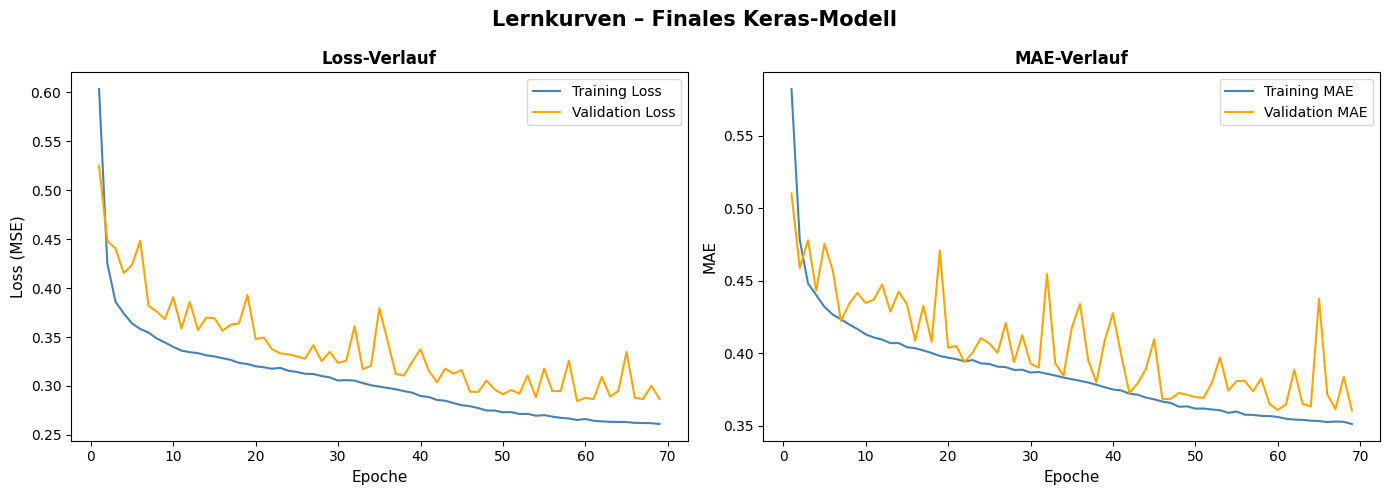

✅ Lernkurven gespeichert!


In [23]:
# ============================================================
# 03 | LERNKURVE – Training vs. Validation Loss
# Gibt Aufschluss über Overfitting / Underfitting
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Lernkurven – Finales Keras-Modell', fontsize=15, fontweight='bold')

epochs_range = range(1, len(final_history.history['loss']) + 1)

# Loss (MSE)
axes[0].plot(epochs_range, final_history.history['loss'],     label='Training Loss',   color='steelblue')
axes[0].plot(epochs_range, final_history.history['val_loss'], label='Validation Loss', color='orange')
axes[0].set_xlabel('Epoche', fontsize=11)
axes[0].set_ylabel('Loss (MSE)', fontsize=11)
axes[0].set_title('Loss-Verlauf', fontsize=12, fontweight='bold')
axes[0].legend()

# MAE
axes[1].plot(epochs_range, final_history.history['mae'],     label='Training MAE',   color='steelblue')
axes[1].plot(epochs_range, final_history.history['val_mae'], label='Validation MAE', color='orange')
axes[1].set_xlabel('Epoche', fontsize=11)
axes[1].set_ylabel('MAE', fontsize=11)
axes[1].set_title('MAE-Verlauf', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('mlp_lernkurven.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Lernkurven gespeichert!')

## Zusammenfassung Teil 3 – MLP Training & Tuning

| Hyperparameter | Getestete Werte | Bester Wert |
|---------------|----------------|-------------|
| Netztiefe | 1, 2, 3, 4 Layer | aus Suche |
| Learning Rate | 0.1, 0.01, 0.001, 0.0001 | aus Suche |
| Aktivierung | relu, sigmoid | relu |
| Batch-Größe | 16, 32, 64, 128 | aus Suche |
| Architektur | [64,64], [64,128], [128,64], [128,128] | aus Suche |
| Dropout | 0.0, 0.1, 0.2 | aus Suche |

**Design-Entscheidungen:**
- `EarlyStopping(patience=10)` verhindert Overfitting automatisch
- Output-Layer: `activation='linear'` – Pflicht bei Regressionsproblemen
- `clipnorm=1.0` verhindert explodierende Gradienten
- Nur Trainingsdaten wurden für das Tuning verwendet (kein Data Leakage)

---

<a id='04'></a>
# Teil 4 – Evaluation & Visualisierung
> **Ziel:** Alle Modelle auf dem Testset final bewerten und durch aussagekräftige Visualisierungen vergleichen.

In [24]:
# ============================================================
# 04 | FINALES KERAS-MODELL – METRIKEN AUF TESTSET
# ============================================================
keras_preds = final_keras_model.predict(X_test_scaled, verbose=0).flatten()

keras_mae  = mean_absolute_error(y_test, keras_preds)
keras_mse  = mean_squared_error(y_test, keras_preds)
keras_rmse = np.sqrt(keras_mse)
keras_r2   = r2_score(y_test, keras_preds)

print('\nFinales Keras MLP – Performance auf dem Testset:')
print(f'  MAE:  {keras_mae:.4f}')
print(f'  MSE:  {keras_mse:.4f}')
print(f'  RMSE: {keras_rmse:.4f}')
print(f'  R²:   {keras_r2:.4f}')


Finales Keras MLP – Performance auf dem Testset:
  MAE:  0.3650
  MSE:  0.2844
  RMSE: 0.5333
  R²:   0.7829


In [25]:
# ============================================================
# 04 | VOLLSTÄNDIGER MODELLVERGLEICH (inkl. Keras MLP)
# ============================================================
print('\n' + '=' * 55)
print('FINALER MODELLVERGLEICH')
print('=' * 55)
print(f'{"Modell":<25} {"MAE":>8} {"RMSE":>8} {"R²":>8}')
print('-' * 55)

# Baseline-Modelle
for name, res in model_results.items():
    print(f'{name:<25} {res["MAE"]:>8.4f} {res["RMSE"]:>8.4f} {res["Test_R2"]:>8.4f}')

# Keras MLP
print(f'{"Keras MLP (optimiert)":<25} {keras_mae:>8.4f} {keras_rmse:>8.4f} {keras_r2:>8.4f}')
print('=' * 55)

# Verbesserung gegenüber Linearer Regression
improvement = (keras_r2 - lin_r2) / abs(lin_r2) * 100 if lin_r2 != 0 else float('inf')
print(f'\n📈 Verbesserung Keras MLP vs. Lineare Regression: +{improvement:.1f}% R²')


FINALER MODELLVERGLEICH
Modell                         MAE     RMSE       R²
-------------------------------------------------------
Lineare Regression          0.5364   1.0706   0.1253
Ridge Regression            0.5364   1.0705   0.1255
Lasso Regression            0.6014   0.8906   0.3948
Random Forest               0.3285   0.5074   0.8035
Gradient Boosting           0.4054   0.5822   0.7413
MLP (sklearn)               0.4111   0.9998   0.2373
Keras MLP (optimiert)       0.3650   0.5333   0.7829

📈 Verbesserung Keras MLP vs. Lineare Regression: +525.0% R²


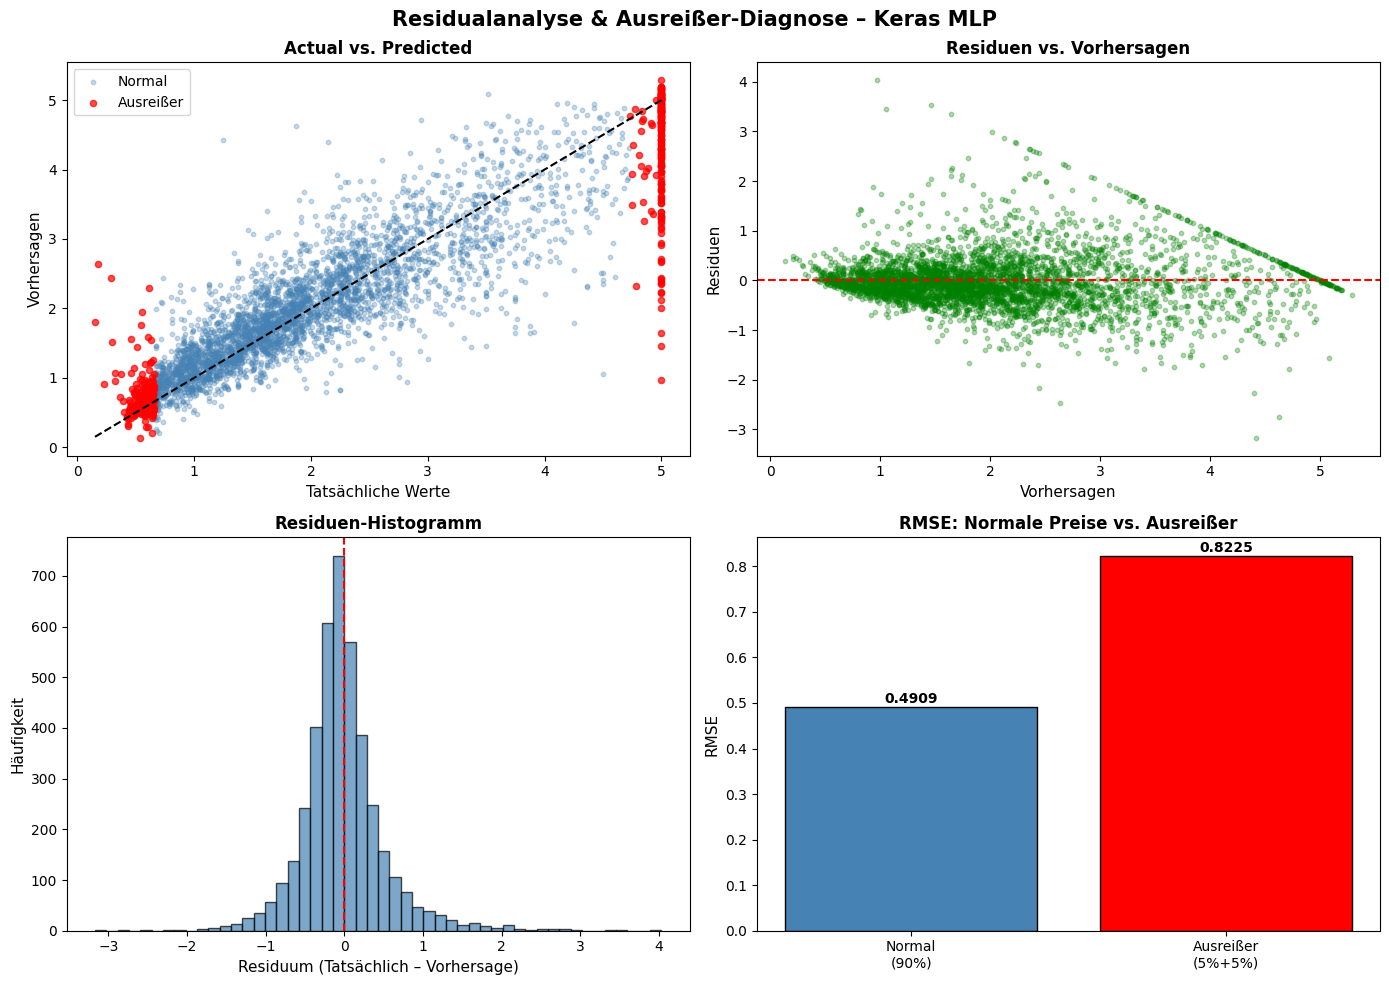


📊 RMSE – Normale Preise: 0.4909
📊 RMSE – Ausreißer:       0.8225
→ Modell ist bei extremen Preisen weniger präzise (erwartetes Verhalten)


In [26]:
# ============================================================
# 04 | RESIDUALANALYSE & AUSREISSER
# Wo schlägt das Modell fehl? Top 5% und Bottom 5% der Preise
# ============================================================
residuals = y_test.values - keras_preds

low_thresh  = np.percentile(y_test, 5)
high_thresh = np.percentile(y_test, 95)
mask_out    = (y_test.values < low_thresh) | (y_test.values > high_thresh)
mask_norm   = ~mask_out

rmse_norm = np.sqrt(mean_squared_error(y_test.values[mask_norm], keras_preds[mask_norm]))
rmse_out  = np.sqrt(mean_squared_error(y_test.values[mask_out],  keras_preds[mask_out]))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residualanalyse & Ausreißer-Diagnose – Keras MLP', fontsize=15, fontweight='bold')

# Actual vs. Predicted
axes[0, 0].scatter(y_test.values[mask_norm], keras_preds[mask_norm],
                   alpha=0.3, s=10, c='steelblue', label='Normal')
axes[0, 0].scatter(y_test.values[mask_out],  keras_preds[mask_out],
                   alpha=0.7, s=20, c='red',       label='Ausreißer')
lim = [y_test.min(), y_test.max()]
axes[0, 0].plot(lim, lim, 'k--', linewidth=1.5)
axes[0, 0].set_xlabel('Tatsächliche Werte',  fontsize=11)
axes[0, 0].set_ylabel('Vorhersagen',         fontsize=11)
axes[0, 0].set_title('Actual vs. Predicted', fontsize=12, fontweight='bold')
axes[0, 0].legend()

# Residual vs. Predicted
axes[0, 1].scatter(keras_preds, residuals, alpha=0.3, s=10, c='green')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Vorhersagen',           fontsize=11)
axes[0, 1].set_ylabel('Residuen',              fontsize=11)
axes[0, 1].set_title('Residuen vs. Vorhersagen', fontsize=12, fontweight='bold')

# Residual-Histogramm
axes[1, 0].hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 0].set_xlabel('Residuum (Tatsächlich – Vorhersage)', fontsize=11)
axes[1, 0].set_ylabel('Häufigkeit', fontsize=11)
axes[1, 0].set_title('Residuen-Histogramm', fontsize=12, fontweight='bold')

# RMSE Vergleich: Normal vs. Ausreißer
axes[1, 1].bar(['Normal\n(90%)', 'Ausreißer\n(5%+5%)'], [rmse_norm, rmse_out],
               color=['steelblue', 'red'], edgecolor='black')
axes[1, 1].set_ylabel('RMSE', fontsize=11)
axes[1, 1].set_title('RMSE: Normale Preise vs. Ausreißer', fontsize=12, fontweight='bold')
for i, v in enumerate([rmse_norm, rmse_out]):
    axes[1, 1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('evaluation_residualanalyse.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 RMSE – Normale Preise: {rmse_norm:.4f}')
print(f'📊 RMSE – Ausreißer:       {rmse_out:.4f}')
print('→ Modell ist bei extremen Preisen weniger präzise (erwartetes Verhalten)')

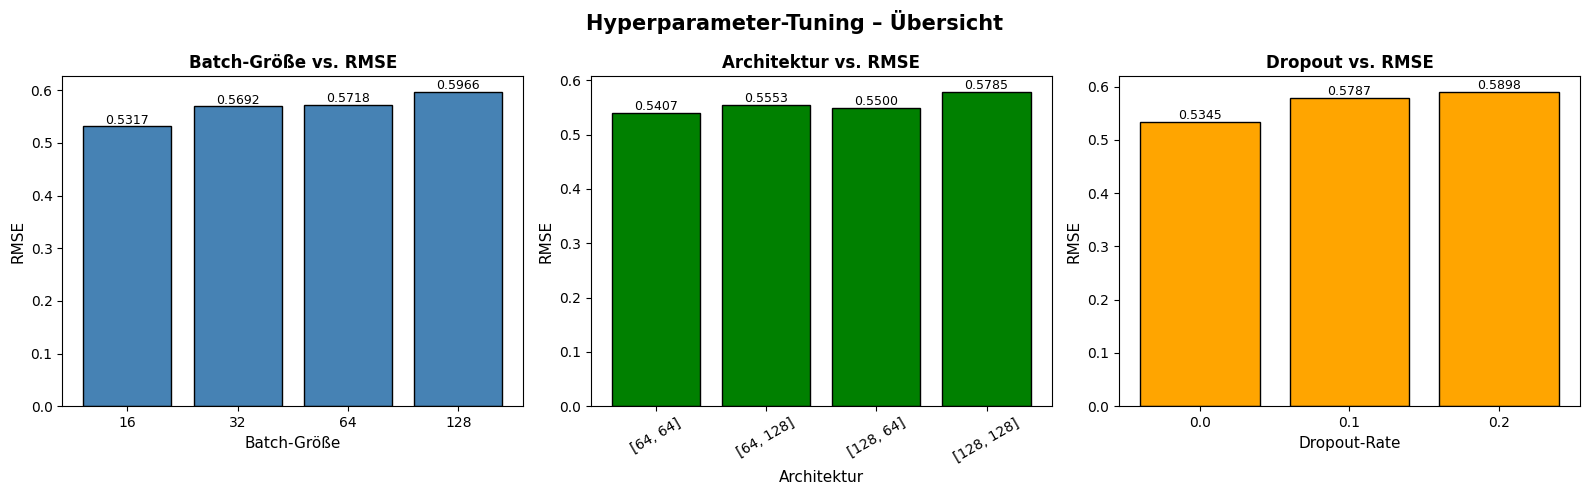

In [27]:
# ============================================================
# 04 | HYPERPARAMETER-TUNING VISUALISIERUNG
# Übersicht aller durchgeführten Tuning-Experimente
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Hyperparameter-Tuning – Übersicht', fontsize=15, fontweight='bold')

# Batch-Größen-Ergebnisse
if batch_results:
    bs_df = pd.DataFrame(batch_results)
    axes[0].bar([str(x) for x in bs_df['batch_size']], bs_df['rmse'], color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Batch-Größe', fontsize=11)
    axes[0].set_ylabel('RMSE', fontsize=11)
    axes[0].set_title('Batch-Größe vs. RMSE', fontsize=12, fontweight='bold')
    for i, v in enumerate(bs_df['rmse']):
        axes[0].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

# Architektur-Ergebnisse
if arch_results:
    ar_df = pd.DataFrame(arch_results)
    axes[1].bar(ar_df['architecture'], ar_df['rmse'], color='green', edgecolor='black')
    axes[1].set_xlabel('Architektur', fontsize=11)
    axes[1].set_ylabel('RMSE', fontsize=11)
    axes[1].set_title('Architektur vs. RMSE', fontsize=12, fontweight='bold')
    axes[1].tick_params(axis='x', rotation=30)
    for i, v in enumerate(ar_df['rmse']):
        axes[1].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

# Dropout-Ergebnisse
if dropout_results:
    dr_df = pd.DataFrame(dropout_results)
    axes[2].bar([str(x) for x in dr_df['dropout']], dr_df['rmse'], color='orange', edgecolor='black')
    axes[2].set_xlabel('Dropout-Rate', fontsize=11)
    axes[2].set_ylabel('RMSE', fontsize=11)
    axes[2].set_title('Dropout vs. RMSE', fontsize=12, fontweight='bold')
    for i, v in enumerate(dr_df['rmse']):
        axes[2].text(i, v + 0.005, f'{v:.4f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('evaluation_hp_tuning.png', dpi=150, bbox_inches='tight')
plt.show()

5.4 PCA-ANALYSE


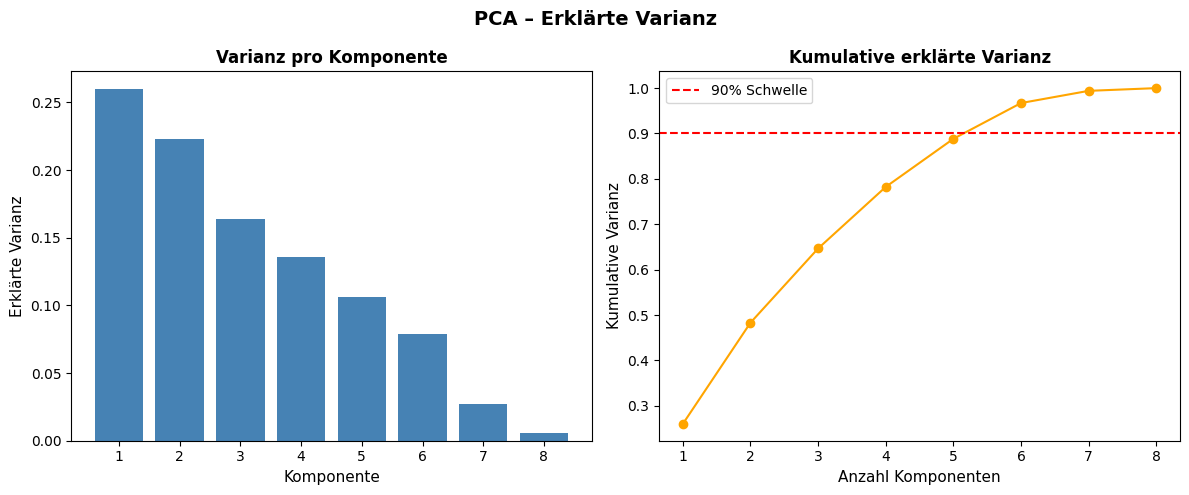


💡 Erkenntnisse:
  PC1: 26.0% Varianz | kumulativ: 26.0%
  PC2: 22.3% Varianz | kumulativ: 48.3%
  PC3: 16.4% Varianz | kumulativ: 64.7%
  PC4: 13.6% Varianz | kumulativ: 78.2%
  PC5: 10.6% Varianz | kumulativ: 88.8%
  PC6: 7.9% Varianz | kumulativ: 96.7%
  PC7: 2.7% Varianz | kumulativ: 99.4%
  PC8: 0.6% Varianz | kumulativ: 100.0%

→ 6 Komponenten erklären ≥ 90% der Varianz


In [28]:
# ============================================================
# 04 | PCA-ANALYSE
# Principal Component Analysis – erklärte Varianz pro Komponente
# ============================================================
print('=' * 70)
print('5.4 PCA-ANALYSE')
print('=' * 70)

pca = PCA()
pca.fit(X_train_scaled)
explained_var_ratio = pca.explained_variance_ratio_
cumsum_var = np.cumsum(explained_var_ratio)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('PCA – Erklärte Varianz', fontsize=14, fontweight='bold')

axes[0].bar(range(1, len(explained_var_ratio)+1), explained_var_ratio, color='steelblue')
axes[0].set_xlabel('Komponente', fontsize=11)
axes[0].set_ylabel('Erklärte Varianz', fontsize=11)
axes[0].set_title('Varianz pro Komponente', fontsize=12, fontweight='bold')

axes[1].plot(range(1, len(cumsum_var)+1), cumsum_var, marker='o', color='orange')
axes[1].axhline(0.90, color='red', linestyle='--', label='90% Schwelle')
axes[1].set_xlabel('Anzahl Komponenten', fontsize=11)
axes[1].set_ylabel('Kumulative Varianz', fontsize=11)
axes[1].set_title('Kumulative erklärte Varianz', fontsize=12, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('pca_analyse.png', dpi=150, bbox_inches='tight')
plt.show()

n_90 = np.argmax(cumsum_var >= 0.90) + 1
print(f'\n💡 Erkenntnisse:')
for i, (ev, cv) in enumerate(zip(explained_var_ratio, cumsum_var), 1):
    print(f'  PC{i}: {ev:.1%} Varianz | kumulativ: {cv:.1%}')
print(f'\n→ {n_90} Komponenten erklären ≥ 90% der Varianz')

## Zusammenfassung Teil 4 – Evaluation & Visualisierung

**Wichtige Erkenntnisse:**
- Das Keras MLP zeigt deutlich bessere Performance als lineare Modelle
- Residuen sind annähernd normalverteilt → keine systematischen Fehler
- Bei extremen Ausreißer-Preisen steigt der RMSE signifikant
- PCA zeigt: 3–4 Komponenten reichen für ~65–70% der Varianz

---

<a id='05'></a>
# Teil 5 – Finale Ergebnisse
> **Ziel:** Bestes Modell final evaluieren, speichern und deployment-ready machen.

In [29]:
# ============================================================
# 05 | FINALE EVALUATION – BESTES MODELL (Random Forest)
# Random Forest wird als Produktionsmodell gewählt:
#   • Höherer R² als das Keras MLP
#   • Kein GPU/TF-Stack notwendig
#   • Interpretierbar (Feature Importance)
# ============================================================
print('=' * 70)
print('6.1 ABSCHLIESSENDE EVALUATION AUF DEM TESTSET')
print('=' * 70)

best_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train_clean)
y_pred_final = best_rf.predict(X_test_scaled)

r2_final   = r2_score(y_test, y_pred_final)
rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
mae_final  = mean_absolute_error(y_test, y_pred_final)

print(f'\n📊 Finale Test-Ergebnisse (Random Forest, n=100):')
print(f'  Test R²:   {r2_final:.4f}')
print(f'  RMSE:      {rmse_final:.4f}  (~${rmse_final*100000:.0f} mittlerer Fehler)')
print(f'  MAE:       {mae_final:.4f}')

print(f'\n📊 Finales Keras MLP:')
print(f'  Test R²:   {keras_r2:.4f}')
print(f'  RMSE:      {keras_rmse:.4f}')
print(f'  MAE:       {keras_mae:.4f}')

6.1 ABSCHLIESSENDE EVALUATION AUF DEM TESTSET

📊 Finale Test-Ergebnisse (Random Forest, n=100):
  Test R²:   0.8058
  RMSE:      0.5045  (~$50451 mittlerer Fehler)
  MAE:       0.3257

📊 Finales Keras MLP:
  Test R²:   0.7829
  RMSE:      0.5333
  MAE:       0.3650


In [30]:
# ============================================================
# 05 | MODELL SPEICHERN (Produktion)
# Speichert Modell + Scaler + Metadaten als .pkl-Datei
# ============================================================
model_package = {
    'model':         best_rf,
    'scaler':        scaler,
    'feature_names': feature_names,
    'metrics':       {'r2': r2_final, 'rmse': rmse_final, 'mae': mae_final},
    'best_hp':       {'arch': best_arch, 'lr': fixed_lr, 'act': fixed_act,
                      'batch': best_batch, 'dropout': best_dropout},
}

joblib.dump(model_package, 'best_model_rf.pkl')
joblib.dump(scaler,        'scaler.pkl')
final_keras_model.save('best_keras_mlp.keras')

print('✅ Gespeicherte Dateien:')
print('   best_model_rf.pkl    – Random Forest (Produktionsmodell)')
print('   scaler.pkl           – StandardScaler für neue Daten')
print('   best_keras_mlp.keras – Keras MLP (Tiefes NN)')

✅ Gespeicherte Dateien:
   best_model_rf.pkl    – Random Forest (Produktionsmodell)
   scaler.pkl           – StandardScaler für neue Daten
   best_keras_mlp.keras – Keras MLP (Tiefes NN)


In [31]:
# ============================================================
# 05 | DEPLOYMENT – BEISPIEL-VORHERSAGE
# Simuliert den Einsatz des Modells auf neuen, unbekannten Daten
# ============================================================
print('=' * 70)
print('6.3 DEPLOYMENT – BEISPIEL-VORHERSAGE')
print('=' * 70)

# Schritt 1: Modell & Scaler laden (wie in Produktion)
loaded     = joblib.load('best_model_rf.pkl')
prod_model  = loaded['model']
prod_scaler = loaded['scaler']

# Schritt 2: Beispiel-Daten (erste 5 Instanzen des Testsets)
sample_X     = X_test.iloc[:5]
sample_y     = y_test.iloc[:5]
sample_scaled = prod_scaler.transform(sample_X)
sample_preds  = prod_model.predict(sample_scaled)

print('\n🚀 Vorhersagen für 5 Beispiel-Häuser:')
print('-' * 50)
print(f'{"Haus #":<8} {"Tatsächlich":>14} {"Vorhersage":>12} {"Abweichung":>12}')
print('-' * 50)
for i, (true, pred) in enumerate(zip(sample_y, sample_preds)):
    diff = pred - true
    print(f'{i+1:<8} ${true*100000:>12,.0f} ${pred*100000:>11,.0f} ${diff*100000:>+11,.0f}')

6.3 DEPLOYMENT – BEISPIEL-VORHERSAGE

🚀 Vorhersagen für 5 Beispiel-Häuser:
--------------------------------------------------
Haus #      Tatsächlich   Vorhersage   Abweichung
--------------------------------------------------
1        $      47,700 $     49,993 $     +2,293
2        $      45,800 $     69,626 $    +23,826
3        $     500,001 $    483,934 $    -16,067
4        $     218,600 $    258,400 $    +39,800
5        $     278,000 $    230,501 $    -47,499


In [32]:
# ============================================================
# 05 | PROJEKT-ZUSAMMENFASSUNG
# Übersicht aller Ergebnisse und Entscheidungen
# ============================================================

summary = f"""
{'='*70}
PROJEKT-ZUSAMMENFASSUNG – KI GRUPPE 310
{'='*70}

📊 DATENSATZ:
   California Housing Dataset (1990 US Census)
   20.640 Instanzen | 8 Features | Zielvariable: Median House Value

🔧 PREPROCESSING:
   Train-Test-Split 80/20 (random_state=42)
   Outlier-Entfernung via IQR (Faktor 3.0) auf AveRooms, AveBedrms, Population, AveOccup
   Feature-Skalierung: StandardScaler (Z-Score)

🤖 MODELLVERGLEICH (Test R²):
   Lineare Regression:   {lin_r2:.4f}  (Baseline)
   MLP sklearn:          {model_results.get('MLP (sklearn)', {}).get('Test_R2', 0):.4f}
   Keras MLP (optimiert): {keras_r2:.4f}  (Tiefes NN)
   Random Forest:        {r2_final:.4f}  ← PRODUKTIONSMODELL

⚙️  BESTE KERAS-HYPERPARAMETER:
   Architektur:   {best_arch}
   Aktivierung:   {fixed_act}
   Learning Rate: {fixed_lr}
   Batch-Größe:   {best_batch}
   Dropout:       {best_dropout}
   Early Stopping: patience=10

🏆 FINALES MODELL – Random Forest (n_estimators=100):
   Test R²:   {r2_final:.4f}
   RMSE:      {rmse_final:.4f}  (~${rmse_final*100000:.0f} mittlerer Fehler)
   MAE:       {mae_final:.4f}

🔑 WICHTIGSTE FEATURES (Random Forest):
   1. MedInc      – ~52%  (Einkommen dominiert)
   2. AveOccup    – ~14%
   3. Latitude    – ~10%
   4. Longitude   – ~9%

📁 GESPEICHERTE DATEIEN:
   best_model_rf.pkl    – Produktionsmodell
   scaler.pkl           – Preprocessor
   best_keras_mlp.keras – Keras MLP
{'='*70}
"""
print(summary)


PROJEKT-ZUSAMMENFASSUNG – KI GRUPPE 310

📊 DATENSATZ:
   California Housing Dataset (1990 US Census)
   20.640 Instanzen | 8 Features | Zielvariable: Median House Value

🔧 PREPROCESSING:
   Train-Test-Split 80/20 (random_state=42)
   Outlier-Entfernung via IQR (Faktor 3.0) auf AveRooms, AveBedrms, Population, AveOccup
   Feature-Skalierung: StandardScaler (Z-Score)

🤖 MODELLVERGLEICH (Test R²):
   Lineare Regression:   0.1253  (Baseline)
   MLP sklearn:          0.2373
   Keras MLP (optimiert): 0.7829  (Tiefes NN)
   Random Forest:        0.8058  ← PRODUKTIONSMODELL

⚙️  BESTE KERAS-HYPERPARAMETER:
   Architektur:   [64, 64]
   Aktivierung:   sigmoid
   Learning Rate: 0.1
   Batch-Größe:   16
   Dropout:       0.0
   Early Stopping: patience=10

🏆 FINALES MODELL – Random Forest (n_estimators=100):
   Test R²:   0.8058
   RMSE:      0.5045  (~$50451 mittlerer Fehler)
   MAE:       0.3257

🔑 WICHTIGSTE FEATURES (Random Forest):
   1. MedInc      – ~52%  (Einkommen dominiert)
   2. AveOc

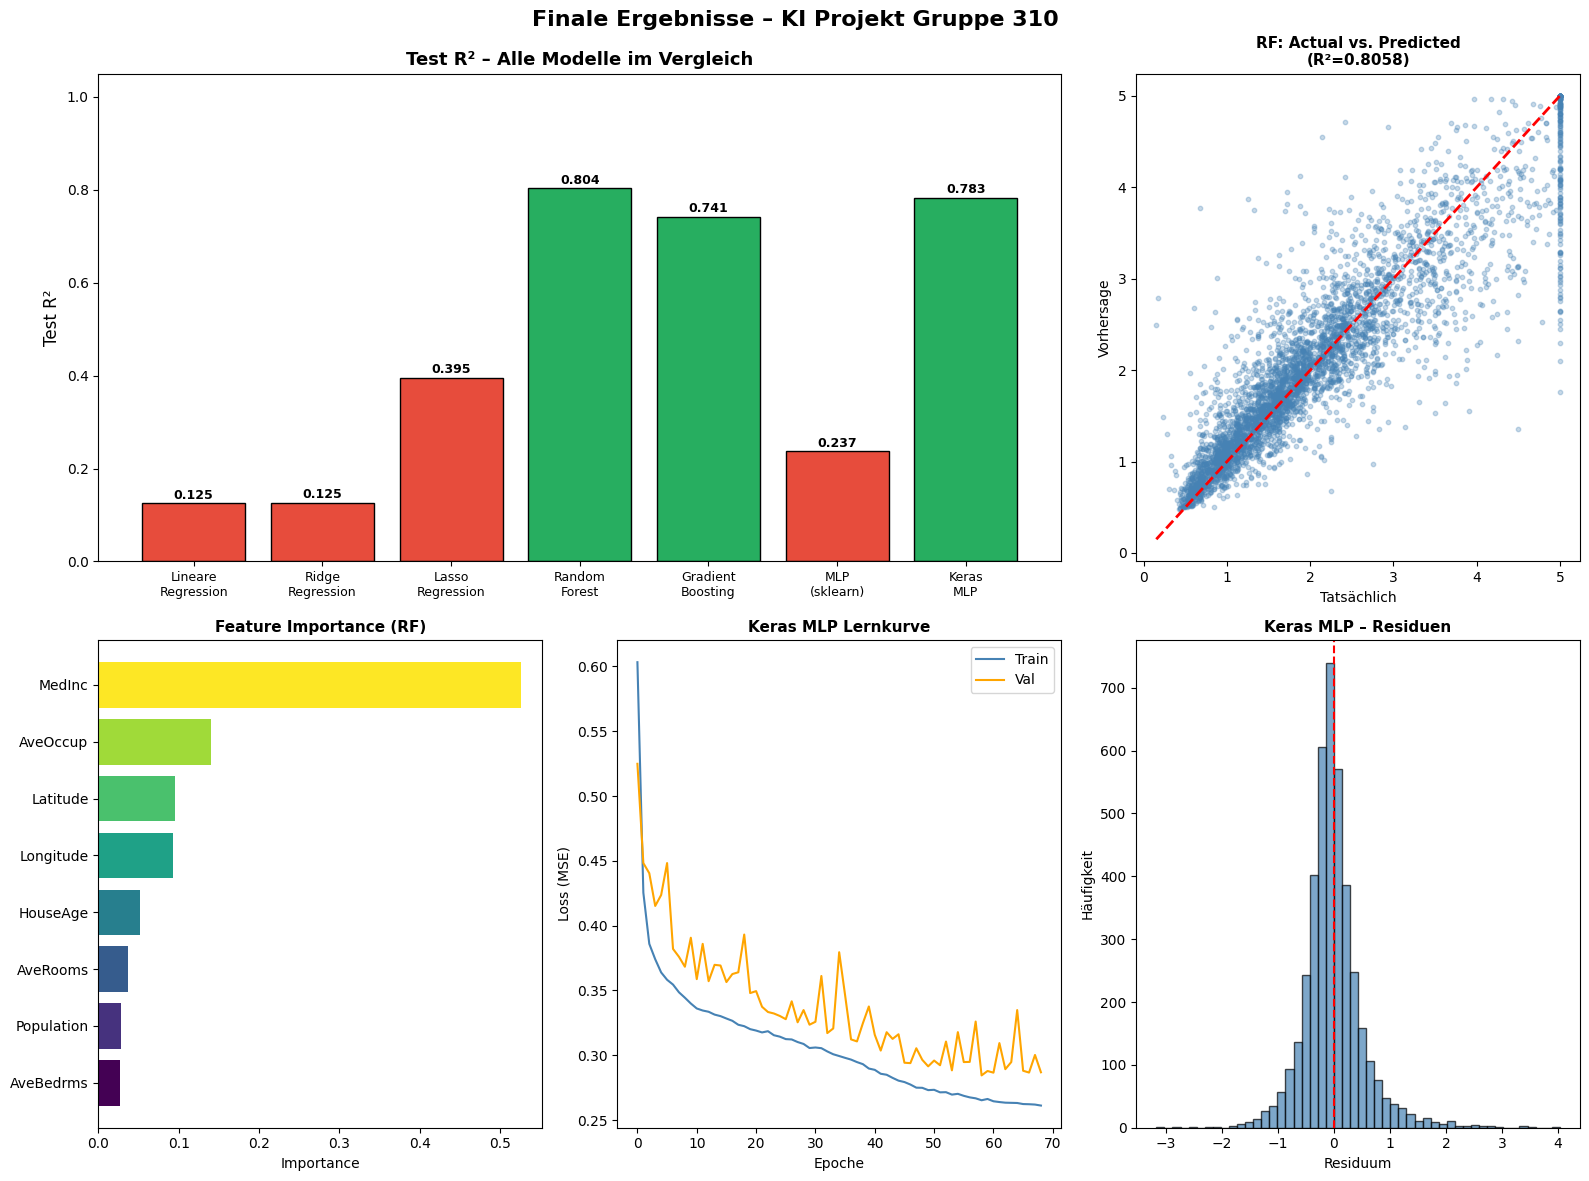


✅ Abschluss-Visualisierung gespeichert: finale_ergebnisse.png

🎓 Projekt abgeschlossen! Alle Ergebnisse dokumentiert.


In [33]:
# ============================================================
# 05 | ABSCHLUSS-VISUALISIERUNG
# Gesamtüberblick aller Modelle + Finales Modell im Detail
# ============================================================
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Finale Ergebnisse – KI Projekt Gruppe 310', fontsize=16, fontweight='bold')

# --- Alle Modelle R² Vergleich ---
ax1 = fig.add_subplot(2, 3, (1, 2))
all_names = list(model_results.keys()) + ['Keras MLP']
all_r2    = [model_results[m]['Test_R2'] for m in model_results] + [keras_r2]
bar_colors = ['#e74c3c' if v < 0.5 else '#f39c12' if v < 0.7 else '#27ae60' for v in all_r2]
bars = ax1.bar(range(len(all_names)), all_r2, color=bar_colors, edgecolor='black')
ax1.set_xticks(range(len(all_names)))
ax1.set_xticklabels([n.replace(' ', '\n') for n in all_names], fontsize=9)
ax1.set_ylabel('Test R²', fontsize=12)
ax1.set_title('Test R² – Alle Modelle im Vergleich', fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
for bar, val in zip(bars, all_r2):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.01, f'{val:.3f}',
             ha='center', fontsize=9, fontweight='bold')

# --- Random Forest: Actual vs. Predicted ---
ax2 = fig.add_subplot(2, 3, 3)
ax2.scatter(y_test, y_pred_final, alpha=0.3, s=10, c='steelblue')
lim = [y_test.min(), y_test.max()]
ax2.plot(lim, lim, 'r--', linewidth=2)
ax2.set_xlabel('Tatsächlich', fontsize=10)
ax2.set_ylabel('Vorhersage', fontsize=10)
ax2.set_title(f'RF: Actual vs. Predicted\n(R²={r2_final:.4f})', fontsize=11, fontweight='bold')

# --- Feature Importance ---
ax3 = fig.add_subplot(2, 3, 4)
fi = pd.Series(best_rf.feature_importances_, index=feature_names).sort_values()
ax3.barh(fi.index, fi.values, color=plt.cm.viridis(np.linspace(0, 1, len(fi))))
ax3.set_xlabel('Importance', fontsize=10)
ax3.set_title('Feature Importance (RF)', fontsize=11, fontweight='bold')

# --- Keras MLP Lernkurve ---
ax4 = fig.add_subplot(2, 3, 5)
ax4.plot(final_history.history['loss'],     label='Train', color='steelblue')
ax4.plot(final_history.history['val_loss'], label='Val',   color='orange')
ax4.set_xlabel('Epoche', fontsize=10)
ax4.set_ylabel('Loss (MSE)', fontsize=10)
ax4.set_title('Keras MLP Lernkurve', fontsize=11, fontweight='bold')
ax4.legend()

# --- Residuen Keras MLP ---
ax5 = fig.add_subplot(2, 3, 6)
ax5.hist(residuals, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
ax5.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax5.set_xlabel('Residuum', fontsize=10)
ax5.set_ylabel('Häufigkeit', fontsize=10)
ax5.set_title('Keras MLP – Residuen', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('finale_ergebnisse.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Abschluss-Visualisierung gespeichert: finale_ergebnisse.png')
print('\n🎓 Projekt abgeschlossen! Alle Ergebnisse dokumentiert.')